In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')


# Load the CSV file into a DataFrame
df = pd.read_csv('/content/drive/MyDrive/Data_中英欄位.csv')
display(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(5200, 57)

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define the target variable y
y = df['Supplier Risk（供應商風險等級）']


# Define the features X with only 'Supplier ESG Score（供應商ESG評分）' and 'PO Status（採購單狀態）'
X_selected = df[['Supplier ESG Score（供應商ESG評分）', 'On Time Delivery（是否準時交貨）',
        'Days Late（延誤天數）','PO Status（採購單狀態）']]

# Handle categorical features in X_selected by one-hot encoding 'PO Status（採購單狀態）'
categorical_cols_selected = X_selected.select_dtypes(include='object').columns

if not categorical_cols_selected.empty:
    print(f"對以下類別特徵進行獨熱編碼: {list(categorical_cols_selected)}")
    X_selected = pd.get_dummies(X_selected, columns=categorical_cols_selected, drop_first=True)
else:
    print("沒有找到需要進行獨熱編碼的類別特徵。")

# Perform the train-test split (70% training, 30% testing)
# Using stratify=y to maintain the proportion of 'Supplier Risk' classes in both sets
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y, test_size=0.3, random_state=1, stratify=y
)

print(f"\n選取特徵後的 X 形狀: {X_selected.shape}")
print(f"目標變數 y 形狀: {y.shape}")

print(f"\n訓練特徵集 (X_train_selected) 形狀: {X_train_selected.shape}")
print(f"測試特徵集 (X_test_selected) 形狀: {X_test_selected.shape}")

print(f"訓練目標變數 (y_train_selected) 形狀: {y_train_selected.shape}")
print(f"測試目標變數 (y_test_selected) 形狀: {y_test_selected.shape}")

對以下類別特徵進行獨熱編碼: ['On Time Delivery（是否準時交貨）', 'PO Status（採購單狀態）']

選取特徵後的 X 形狀: (5200, 6)
目標變數 y 形狀: (5200,)

訓練特徵集 (X_train_selected) 形狀: (3640, 6)
測試特徵集 (X_test_selected) 形狀: (1560, 6)
訓練目標變數 (y_train_selected) 形狀: (3640,)
測試目標變數 (y_test_selected) 形狀: (1560,)


### 使用 `X_selected` 訓練模型並評估結果

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Logistic Regression 對於未縮放的特徵比較敏感。
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)


### 邏輯回歸模型

In [4]:
# 使用隨機森林
from sklearn.ensemble import RandomForestClassifier

'''
# 初始化隨機森林模型
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
'''

# 建議調優參數組合
rf_model = RandomForestClassifier(
    n_estimators=200,      # 增加樹的數量，提升穩定性
    max_depth=10,          # 限制樹的深度，防止過度擬合 (可嘗試 5~15)
    min_samples_split=5,   # 節點分割所需的最小樣本數
    class_weight='balanced_subsample', # 比 'balanced' 更適合隨機森林的抽樣特性
    random_state=42
)

# 訓練
rf_model.fit(X_train_selected_scaled, y_train_selected)


# 預測與評估
y_pred_selected = rf_model.predict(X_test_selected_scaled)

### 評估模型性能


--- 模型評估 (使用 X_selected) ---
準確度 (Accuracy): 0.9731

分類報告 (Classification Report):

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       105
         Low       1.00      0.96      0.98       923
      Medium       0.93      1.00      0.96       532

    accuracy                           0.97      1560
   macro avg       0.98      0.98      0.98      1560
weighted avg       0.97      0.97      0.97      1560


混淆矩陣 (Confusion Matrix):



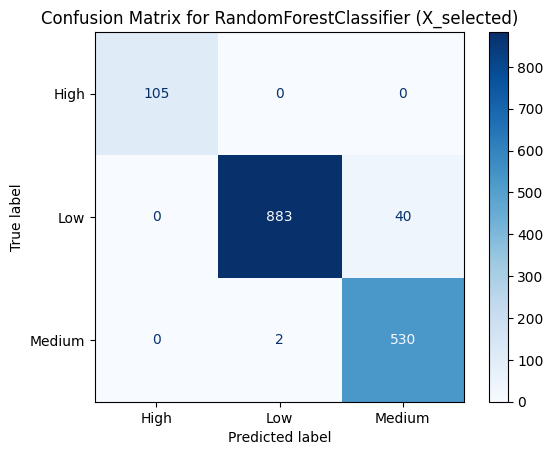

In [5]:
# 5. 評估模型性能
print("\n--- 模型評估 (使用 X_selected) ---")

# 準確度
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
print(f"準確度 (Accuracy): {accuracy_selected:.4f}")

# 分類報告 (包含精確度、召回率、F1-score)
print("\n分類報告 (Classification Report):\n")
print(classification_report(y_test_selected, y_pred_selected))

# 混淆矩陣
print("\n混淆矩陣 (Confusion Matrix):\n")

# model selection:
model=rf_model

# cm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model_selected.classes_)
cm_selected = confusion_matrix(y_test_selected, y_pred_selected, labels=model.classes_)

# display_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selected, display_labels=model_selected.classes_)
display_cm_selected = ConfusionMatrixDisplay(confusion_matrix=cm_selected, display_labels=model.classes_)
display_cm_selected.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for RandomForestClassifier (X_selected)')
plt.show()